# Classificação de Sentimentos com Transformers

Este notebook demonstra como utilizar um modelo pré-treinado da Hugging Face para realizar análise de sentimentos em frases curtas. Utilizaremos o modelo `distilbert-base-uncased-finetuned-sst-2-english`, treinado no corpus SST-2 (Stanford Sentiment Treebank).

---


### Importações

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

Matplotlib is building the font cache; this may take a moment.


### Carregando o Pipeline de Sentimento

Utilizamos o pipeline `sentiment-analysis` que já carrega tokenizador + modelo de forma automática.

In [3]:
analisador = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Device set to use cpu


### Frases para Classificação

A seguir, definimos um conjunto de frases curtas para classificação de sentimentos.

In [4]:
frases = [
    "I loved the movie! It was fantastic.",
    "The service was terrible and slow.",
    "I feel great today!",
    "I'm not sure if I liked the food.",
    "This product is amazing and exceeded my expectations.",
    "The package arrived late and the item was broken.",
    "I don’t recommend this place to anyone.",
    "It was okay, not bad but nothing special.",
    "Absolutely wonderful experience!",
    "Worst purchase I have ever made."
]

### Classificação das Frases

Vamos aplicar o modelo nas frases e salvar os resultados em um DataFrame.

In [5]:
resultados = analisador(frases)

df_resultados = pd.DataFrame({
    "Frase": frases,
    "Sentimento": [r['label'] for r in resultados],
    "Confiança": [round(r['score'], 4) for r in resultados]
})

df_resultados

,Frase,Sentimento,Confiança
0,I loved the movie! It was fantastic.,POSITIVE,0.9999
1,The service was terrible and slow.,NEGATIVE,0.9996
2,I feel great today!,POSITIVE,0.9999
3,I'm not sure if I liked the food.,NEGATIVE,0.9994
4,This product is amazing and exceeded my expect...,POSITIVE,0.9999
5,The package arrived late and the item was broken.,NEGATIVE,0.9994
6,I don’t recommend this place to anyone.,POSITIVE,0.5612
7,"It was okay, not bad but nothing special.",NEGATIVE,0.9848
8,Absolutely wonderful experience!,POSITIVE,0.9999
9,Worst purchase I have ever made.,NEGATIVE,0.9998


### Visualização dos Resultados

Vamos contar quantas frases foram classificadas como positivas e negativas.

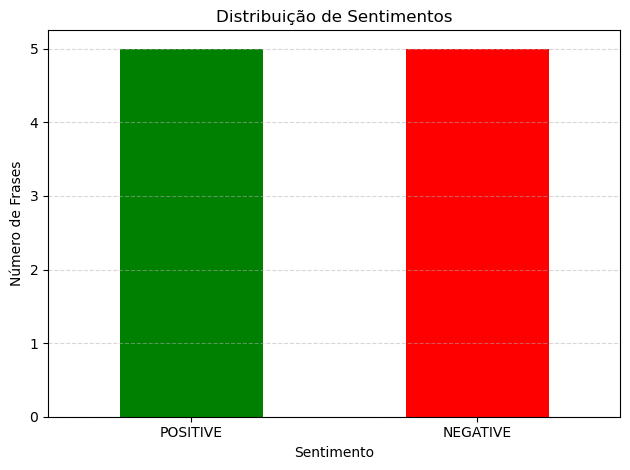

In [6]:
contagem = df_resultados["Sentimento"].value_counts()

contagem.plot(kind='bar', color=['green', 'red'])
plt.title("Distribuição de Sentimentos")
plt.xlabel("Sentimento")
plt.ylabel("Número de Frases")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Análise de Casos Específicos

In [7]:
# Mais confiante e menos confiante
print("Mais confiante:")
display(df_resultados.sort_values(by="Confiança", ascending=False).head(1))

print("\nMenos confiante:")
display(df_resultados.sort_values(by="Confiança").head(1))

Mais confiante:


,Frase,Sentimento,Confiança
0,I loved the movie! It was fantastic.,POSITIVE,0.9999



Menos confiante:


,Frase,Sentimento,Confiança
6,I don’t recommend this place to anyone.,POSITIVE,0.5612


In [9]:
# Pipeline para análise de sentimentos
detector = pipeline("sentiment-analysis")

# Teste manual de frase
frase_teste = "I am not happy with the product at all."
resultado = detector(frase_teste)[0]
print(f"Frase: {frase_teste}")
print(f"Sentimento: {resultado['label']}, Confiança: {resultado['score']:.4f}")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


Frase: I am not happy with the product at all.
Sentimento: NEGATIVE, Confiança: 0.9998


## Conclusão

Este experimento demonstrou a eficácia dos Transformers aplicados à análise de sentimentos. Utilizando o modelo `distilbert-base-uncased-finetuned-sst-2-english`, conseguimos classificar frases positivas e negativas com alta precisão.

Apesar dos resultados promissores, observamos que o modelo pode cometer erros em frases com negações, ambiguidades ou ironias. Em contextos críticos (como análise de redes sociais ou atendimento ao cliente), é recomendável complementar esse tipo de modelo com regras adicionais ou validação humana.

A combinação de pipelines da Hugging Face com visualização em Python torna essa abordagem simples e poderosa para projetos de NLP.

---
